# Lab 03_2. Linear Regression

참돔 길이로 무게 예측하기

## 목표

- 실제 데이터에 Linear Regression(리니어 리그레션, 선형회귀) 적용하기
- `Lab 03_1`의 신경망 학습 구조 그대로 사용하기
- 훈련 데이터와 테스트 데이터 분리하기
- 입력값 표준화로 안정적인 학습 만들기
- 학습된 가중치와 편향으로 회귀식 확인하기
- 결정계수 $R^2$로 예측 성능 평가하기

**Linear regression finds the straight line that best represents the data.**  
**선형회귀는 데이터를 가장 잘 나타내는 직선을 찾습니다.**

## 실습 단계

### 1. 라이브러리 불러오기

In [1]:
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt

# 재현성: 난수 고정
torch.manual_seed(42)

print("PyTorch 버전:", torch.__version__)

PyTorch 버전: 2.13.0+cu130


### 2. 참돔 데이터 준비하기

- 입력 특성 $x$: 참돔 길이(cm)
- 목표값 $y$: 참돔 무게(g)
- 데이터 수: 56개

In [2]:
# 참돔 길이: cm
chamdom_length = np.array(
    [
        8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0,
        19.6, 20.0, 21.0, 21.0, 21.0, 21.3, 22.0, 22.0,
        22.0, 22.0, 22.0, 22.5, 22.5, 22.7, 23.0, 23.5,
        24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5,
        27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0,
        36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0,
        40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5, 44.0,
    ],
    dtype=np.float32,
)

# 참돔 무게: g
chamdom_weight = np.array(
    [
        5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0,
        85.0, 85.0, 110.0, 115.0, 125.0, 130.0, 120.0, 120.0,
        130.0, 135.0, 110.0, 130.0, 150.0, 145.0, 150.0, 170.0,
        225.0, 145.0, 188.0, 180.0, 197.0, 218.0, 300.0, 260.0,
        265.0, 250.0, 250.0, 300.0, 320.0, 514.0, 556.0, 840.0,
        685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0, 850.0,
        900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0, 1000.0,
    ],
    dtype=np.float32,
)

print("데이터 수:", len(chamdom_length))
print("길이 범위:", chamdom_length.min(), "~", chamdom_length.max(), "cm")
print("무게 범위:", chamdom_weight.min(), "~", chamdom_weight.max(), "g")

데이터 수: 56
길이 범위: 8.4 ~ 44.0 cm
무게 범위: 5.9 ~ 1100.0 g


### 3. 데이터 분포 확인하기

길이가 증가할수록 무게도 대체로 증가합니다.  
따라서 길이와 무게의 관계를 직선으로 먼저 학습합니다.

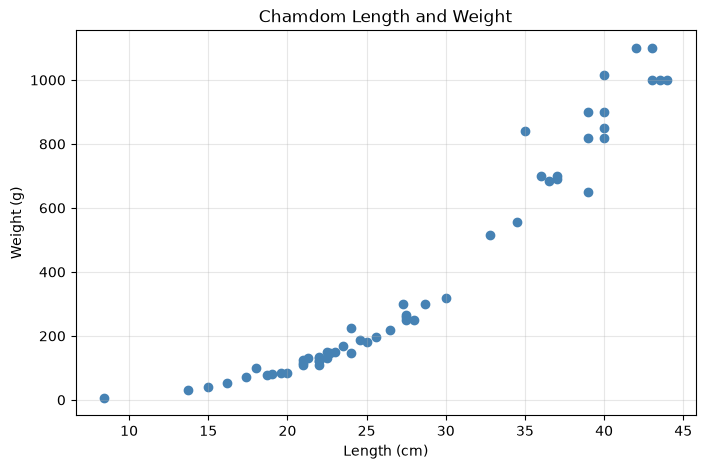

In [3]:
# 산점도
plt.figure(figsize=(8, 5))
plt.scatter(chamdom_length, chamdom_weight, color="steelblue")
plt.xlabel("Length (cm)")
plt.ylabel("Weight (g)")
plt.title("Chamdom Length and Weight")
plt.grid(alpha=0.3)
plt.show()

### 4. 훈련 데이터와 테스트 데이터 나누기

- 훈련 데이터: 모델의 가중치와 편향 학습
- 테스트 데이터: 학습에 사용하지 않은 데이터로 성능 확인
- 분할 비율: 훈련 75%, 테스트 25%

`nn.Linear(1, 1)`에 입력하기 위해 형상을 `[데이터 수, 특성 수]`로 만듭니다.

In [4]:
# 인덱스 무작위 배치
random_generator = np.random.RandomState(42)
shuffled_indices = random_generator.permutation(len(chamdom_length))

# 훈련 42개·테스트 14개
test_indices = shuffled_indices[:14]
train_indices = shuffled_indices[14:]

# 데이터 분리
x_train_np = chamdom_length[train_indices]
x_test_np = chamdom_length[test_indices]
y_train_np = chamdom_weight[train_indices]
y_test_np = chamdom_weight[test_indices]

# NumPy 배열 → PyTorch 텐서
# 입력 형상: [데이터 수, 특성 수]
x_train = torch.tensor(x_train_np).reshape(-1, 1)
x_test = torch.tensor(x_test_np).reshape(-1, 1)
y_train = torch.tensor(y_train_np).reshape(-1, 1)
y_test = torch.tensor(y_test_np).reshape(-1, 1)

print("훈련 입력:", x_train.shape)
print("훈련 목표:", y_train.shape)
print("테스트 입력:", x_test.shape)
print("테스트 목표:", y_test.shape)

훈련 입력: torch.Size([42, 1])
훈련 목표: torch.Size([42, 1])
테스트 입력: torch.Size([14, 1])
테스트 목표: torch.Size([14, 1])


### 5. 입력값 표준화하기

참돔 길이를 평균 0, 표준편차 1에 가까운 값으로 바꿉니다.

$$
x_{scaled}=\frac{x-\mu}{\sigma}
$$

- $\mu$: 훈련 데이터 평균
- $\sigma$: 훈련 데이터 표준편차
- 평균과 표준편차: 훈련 데이터에서만 계산
- 목적: 경사하강법의 안정적인 학습

In [5]:
# 훈련 데이터 기준
x_mean = x_train.mean()
x_std = x_train.std()

# 입력 표준화
x_train_scaled = (x_train - x_mean) / x_std
x_test_scaled = (x_test - x_mean) / x_std

print("표준화 전 평균:", x_train.mean().item())
print("표준화 후 평균:", x_train_scaled.mean().item())
print("표준화 후 표준편차:", x_train_scaled.std().item())

표준화 전 평균: 28.445236206054688
표준화 후 평균: 2.2280784151007538e-07
표준화 후 표준편차: 1.0


### 6. 선형회귀 모델 정의하기

`Lab 02_2`의 모델 구조를 그대로 사용합니다.

$$
\hat{y}=Wx+b
$$

이번 단계의 변경점은 모델이 아니라 학습 데이터입니다.

In [6]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()

        # 선형 계층: 입력 1개 → 출력 1개
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        # 순전파
        prediction = self.linear(x)
        return prediction


model = LinearRegressionModel()
print(model)

LinearRegressionModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)


### 7. 손실함수와 최적화 도구 정의하기

- 손실함수: `nn.MSELoss()`(엔엔 엠에스이 로스, 평균제곱오차 손실함수)
- 최적화 도구: `SGD`(에스지디, 확률적 경사하강법)
- 학습 대상: `model.parameters()`

In [7]:
# 손실함수
loss_function = nn.MSELoss()

# 최적화 도구
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

### 8. 모델 학습하기

`Lab 03_1`의 학습 순서를 그대로 적용합니다.

1. 순전파
2. 손실 계산
3. 기울기 초기화
4. 역전파
5. 가중치와 편향 갱신

In [8]:
epochs = 2000
loss_history = []

for epoch in range(epochs):
    # 순전파·손실
    prediction = model(x_train_scaled)
    loss = loss_function(prediction, y_train)

    # 초기화·역전파·갱신
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 손실 기록
    loss_history.append(loss.item())

    if epoch == 0 or (epoch + 1) % 400 == 0:
        print(
            f"epoch: {epoch + 1:4d} | "
            f"loss: {loss.item():.4f}"
        )

epoch:    1 | loss: 282888.5625
epoch:  400 | loss: 7422.9531
epoch:  800 | loss: 7422.9531
epoch: 1200 | loss: 7422.9531
epoch: 1600 | loss: 7422.9531
epoch: 2000 | loss: 7422.9531


### 9. 손실 변화 확인하기

학습이 진행될수록 MSE(엠에스이, 평균제곱오차)가 감소합니다.

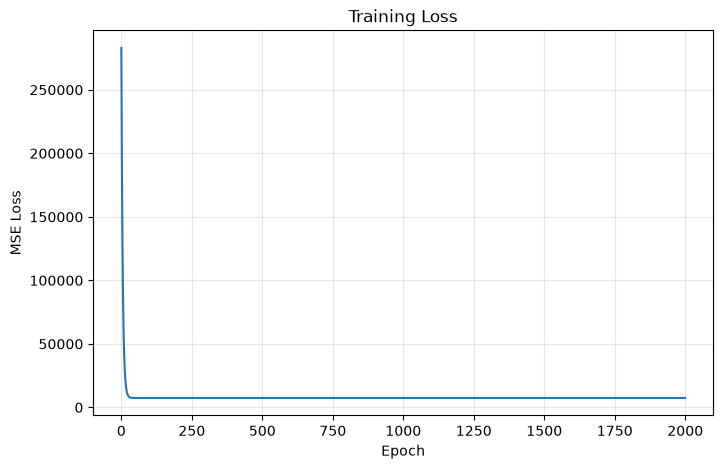

In [9]:
# 손실 곡선
plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss")
plt.grid(alpha=0.3)
plt.show()

### 10. 실제 단위의 회귀식 구하기

모델은 표준화된 길이를 입력받습니다.  
학습된 매개변수를 cm와 g 단위의 회귀식으로 다시 바꿉니다.

$$
\hat{y}=W_{real}x+b_{real}
$$

In [10]:
# 표준화된 입력 기준 매개변수
scaled_weight = model.linear.weight.item()
scaled_bias = model.linear.bias.item()

# 실제 단위의 매개변수
real_weight = scaled_weight / x_std.item()
real_bias = scaled_bias - scaled_weight * x_mean.item() / x_std.item()

print(f"학습된 회귀식: 무게 = {real_weight:.4f} × 길이 {real_bias:+.4f}")
print(f"가중치 W: {real_weight:.4f} g/cm")
print(f"편향 b: {real_bias:.4f} g")

학습된 회귀식: 무게 = 39.0171 × 길이 -709.0183
가중치 W: 39.0171 g/cm
편향 b: -709.0183 g


### 11. 50 cm 참돔 무게 예측하기

50 cm는 학습 데이터의 최대 길이인 44 cm보다 큽니다.  
선형회귀는 학습 범위 밖에서도 학습한 직선을 연장해 예측할 수 있습니다.

In [11]:
# 새 입력
new_length = torch.tensor([[50.0]])
new_length_scaled = (new_length - x_mean) / x_std

# 예측
model.eval()
with torch.no_grad():
    predicted_weight = model(new_length_scaled)

print(f"50 cm 참돔의 예상 무게: {predicted_weight.item():.1f} g")

50 cm 참돔의 예상 무게: 1241.8 g


### 12. 회귀 직선 확인하기

- 파란 점: 전체 참돔 데이터
- 빨간 선: 학습된 선형회귀 직선
- 초록 삼각형: 50 cm 참돔 예측값

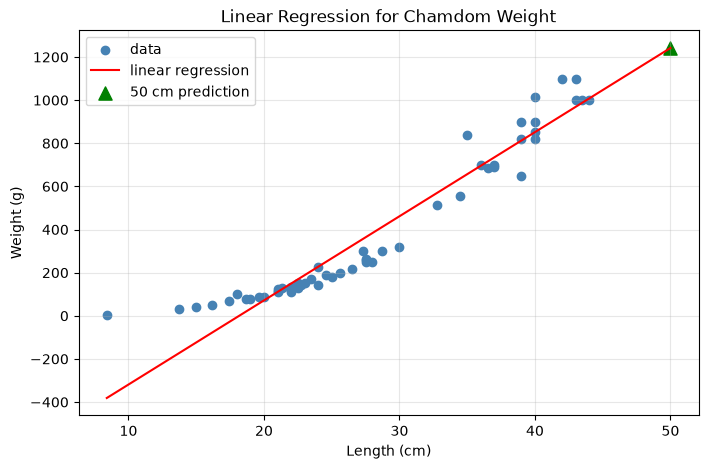

In [12]:
# 회귀 직선용 입력
line_length = torch.linspace(
    chamdom_length.min(),
    50.0,
    steps=100,
).reshape(-1, 1)
line_length_scaled = (line_length - x_mean) / x_std

# 회귀 직선 예측
with torch.no_grad():
    line_weight = model(line_length_scaled)

# 데이터·회귀 직선
plt.figure(figsize=(8, 5))
plt.scatter(chamdom_length, chamdom_weight, color="steelblue", label="data")
plt.plot(
    line_length.squeeze().numpy(),
    line_weight.squeeze().numpy(),
    color="red",
    label="linear regression",
)
plt.scatter(
    [50.0],
    [predicted_weight.item()],
    color="green",
    marker="^",
    s=90,
    label="50 cm prediction",
)
plt.xlabel("Length (cm)")
plt.ylabel("Weight (g)")
plt.title("Linear Regression for Chamdom Weight")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### 13. 평가 지표로 성능 확인하기

한 가지 지표만으로는 모델의 성능을 충분히 판단하기 어렵습니다.  
오차의 크기와 데이터 변화의 설명 정도를 함께 확인합니다.

#### MAE(엠에이이, 평균절대오차)

$$
MAE=\frac{1}{n}\sum|y-\hat{y}|
$$

- 실제값과 예측값 차이의 절댓값 평균
- 단위: g
- 의미: 평균적으로 몇 g 정도 틀리는지 표시
- 값이 작을수록 좋은 모델

#### RMSE(알엠에스이, 평균제곱근오차)

$$
RMSE=\sqrt{\frac{1}{n}\sum(y-\hat{y})^2}
$$

- 큰 오차에 더 큰 영향을 받는 지표
- 단위: g
- MAE보다 크게 증가하면 일부 예측의 오차가 크다는 의미
- 값이 작을수록 좋은 모델

#### $R^2$(알 스퀘어, 결정계수)

$$
R^2=1-\frac{\sum(y-\hat{y})^2}{\sum(y-\bar{y})^2}
$$

- 1에 가까움: 실제값의 변화를 잘 설명
- 0에 가까움: 평균으로 예측하는 수준
- 음수: 평균으로 예측하는 것보다 성능이 낮음
- 오차의 단위를 직접 알려주지 않으므로 MAE·RMSE와 함께 확인

#### 학습 손실과 평가 지표의 차이

- `MSELoss()`: 역전파에 사용할 학습 기준
- MAE·RMSE: 실제 오차를 g 단위로 해석
- $R^2$: 모델이 무게 변화의 경향을 얼마나 설명하는지 확인
- 훈련 성능만 좋고 테스트 성능이 낮으면 과대적합 가능성 확인

In [13]:
def calculate_metrics(y_true, y_pred):
    # 평균절대오차
    mae = torch.mean(torch.abs(y_true - y_pred))

    # 평균제곱근오차
    rmse = torch.sqrt(torch.mean((y_true - y_pred) ** 2))

    # 잔차 제곱합
    residual_sum = torch.sum((y_true - y_pred) ** 2)

    # 전체 제곱합
    total_sum = torch.sum((y_true - y_true.mean()) ** 2)

    # 결정계수
    r2 = 1 - residual_sum / total_sum

    return mae, rmse, r2


model.eval()
with torch.no_grad():
    train_prediction = model(x_train_scaled)
    test_prediction = model(x_test_scaled)

train_mae, train_rmse, train_r2 = calculate_metrics(
    y_train,
    train_prediction,
)
test_mae, test_rmse, test_r2 = calculate_metrics(
    y_test,
    test_prediction,
)

print("[훈련 데이터]")
print(f"MAE : {train_mae.item():.2f} g")
print(f"RMSE: {train_rmse.item():.2f} g")
print(f"R²  : {train_r2.item():.4f}")

print("\n[테스트 데이터]")
print(f"MAE : {test_mae.item():.2f} g")
print(f"RMSE: {test_rmse.item():.2f} g")
print(f"R²  : {test_r2.item():.4f}")

[훈련 데이터]
MAE : 64.89 g
RMSE: 86.16 g
R²  : 0.9398

[테스트 데이터]
MAE : 94.46 g
RMSE: 132.63 g
R²  : 0.8248


## 확인 실습

25 cm, 35 cm, 40 cm 참돔의 무게를 한 번에 예측합니다.

- 입력 형상: `[3, 1]`
- 예측 형상: `[3, 1]`
- 기울기 계산: 사용하지 않음

In [14]:
# 확인용 길이
practice_length = torch.tensor(
    [[25.0], [35.0], [40.0]],
    dtype=torch.float32,
)

# 입력 표준화
practice_length_scaled = (practice_length - x_mean) / x_std

# 무게 예측
model.eval()
with torch.no_grad():
    practice_weight = model(practice_length_scaled)

for length, weight in zip(practice_length, practice_weight):
    print(f"{length.item():.0f} cm → {weight.item():.1f} g")

25 cm → 266.4 g
35 cm → 656.6 g
40 cm → 851.7 g


## 실행 확인

아래 셀에서 오류가 없으면 `Lab 03_2`가 정상적으로 완료된 것입니다.

In [15]:
assert len(chamdom_length) == 56
assert len(chamdom_weight) == 56
assert x_train.shape == torch.Size([42, 1])
assert x_test.shape == torch.Size([14, 1])
assert isinstance(model, nn.Module)
assert isinstance(model.linear, nn.Linear)
assert loss_history[-1] < loss_history[0]
assert 38.0 < real_weight < 40.0
assert -730.0 < real_bias < -690.0
assert 1200.0 < predicted_weight.item() < 1300.0
assert train_r2.item() > 0.90
assert test_r2.item() > 0.80
assert train_mae.item() > 0
assert test_mae.item() > 0
assert train_rmse.item() >= train_mae.item()
assert test_rmse.item() >= test_mae.item()
assert practice_weight.shape == torch.Size([3, 1])

print("Lab 03_2 실행 확인 완료")

Lab 03_2 실행 확인 완료


## 핵심 정리

- 입력 특성: 참돔 길이 1개
- 목표값: 참돔 무게
- 모델: `nn.Linear(1, 1)`
- 손실함수: `nn.MSELoss()`
- 최적화 도구: `SGD`
- 입력 전처리: 훈련 데이터 기준 표준화
- 학습 결과: 길이와 무게를 나타내는 직선
- 성능 평가: MAE·RMSE·$R^2$
- 평가 방법: PyTorch 수식으로 직접 계산
- 범위 밖 예측: 50 cm 참돔 무게 약 1,242 g
